<a href="https://colab.research.google.com/github/hamidb201214-svg/Lectures/blob/main/12_Time_Series_Models_v3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Forecasting in Python

## Models
1. **ARIMA**
2. **SARIMA**
3. **Prophet**
4. **Decision Tree**
5. **XGBoost**

We use the **AirPassengers** dataset and compare all models using the same chronological train/test split.

The goal is to keep the code simple and suitable for teaching.


In [1]:
# Run once if needed
# %pip install pandas numpy matplotlib scikit-learn xgboost statsmodels prophet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

np.random.seed(123)


## 1. Load the data

The AirPassengers dataset contains monthly international airline passenger numbers from 1949 to 1960.


In [2]:
url = "https://raw.githubusercontent.com/aaubs/ds-master/main/data/air_passengers.csv"

df = pd.read_csv(url)

df = df.rename(columns={"#Passengers": "Passengers"})
df["date"] = pd.to_datetime(df["Month"])
df = df[["date", "Passengers"]]

df.head()


,date,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


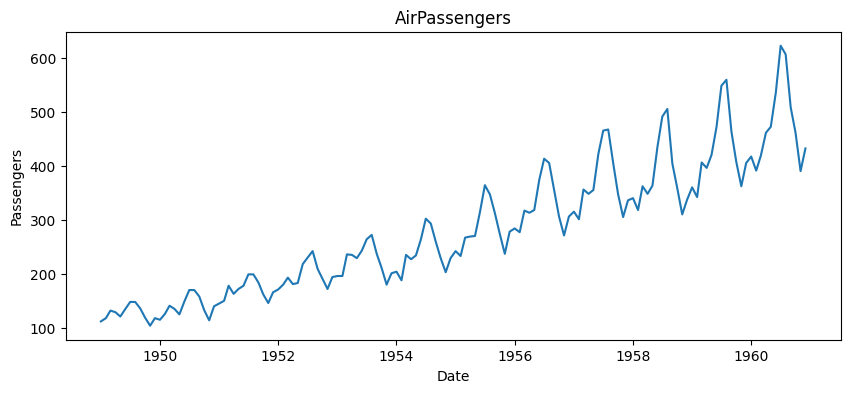

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(df["date"], df["Passengers"])
plt.title("AirPassengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.show()


## 2. Train / Test Split

For time-series data, we do **not shuffle** the observations.

We use the first 80% for training and the final 20% for testing.


In [4]:
split = int(len(df) * 0.8)

train = df.iloc[:split].copy()
test = df.iloc[split:].copy()

print("Training observations:", len(train))
print("Test observations:", len(test))


Training observations: 115
Test observations: 29


## 3. ARIMA

In [5]:
# ARIMA(p, d, q)

arima_model = ARIMA(
    train["Passengers"],
    order=(2, 1, 2)
)

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))

arima_pred.head()


,predicted_mean
115,487.825560
116,460.796800
117,451.130922
118,441.145635
119,435.433346


## 4. SARIMA

SARIMA extends ARIMA by adding a seasonal component.

Because AirPassengers is monthly, we use a seasonal period of **12 months**.


In [6]:
sarima_model = SARIMAX(
    train["Passengers"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

sarima_fit = sarima_model.fit(disp=False)

sarima_pred = sarima_fit.forecast(steps=len(test))

sarima_pred.head()


,predicted_mean
115,489.724155
116,429.406225
117,372.216572
118,331.836692
119,362.700073


## 5. Prophet

In [7]:
# Prophet requires columns named:
# ds = date
# y  = target

prophet_train = train.rename(
    columns={
        "date": "ds",
        "Passengers": "y"
    }
)

prophet_model = Prophet(
    yearly_seasonality=True
)

prophet_model.fit(prophet_train)

future = test[["date"]].rename(columns={"date": "ds"})

prophet_forecast = prophet_model.predict(future)

prophet_pred = prophet_forecast["yhat"]

prophet_pred.head()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,yhat
0,448.347697
1,418.428627
2,387.832932
3,361.650206
4,388.553211


## 6. Prepare lag features for Machine Learning

Decision Tree and XGBoost do not automatically understand time.

We therefore create lagged variables:

- `lag_1`: passengers one month ago
- `lag_2`: passengers two months ago
- `lag_12`: passengers twelve months ago


In [8]:
ml_df = df.copy()

ml_df["lag_1"] = ml_df["Passengers"].shift(1)
ml_df["lag_2"] = ml_df["Passengers"].shift(2)
ml_df["lag_12"] = ml_df["Passengers"].shift(12)

ml_df = ml_df.dropna().reset_index(drop=True)

ml_df.head()


,date,Passengers,lag_1,lag_2,lag_12
0,1950-01-01,115,118.0,104.0,112.0
1,1950-02-01,126,115.0,118.0,118.0
2,1950-03-01,141,126.0,115.0,132.0
3,1950-04-01,135,141.0,126.0,129.0
4,1950-05-01,125,135.0,141.0,121.0


In [9]:
split_ml = int(len(ml_df) * 0.8)

train_ml = ml_df.iloc[:split_ml].copy()
test_ml = ml_df.iloc[split_ml:].copy()

features = ["lag_1", "lag_2", "lag_12"]

X_train = train_ml[features]
y_train = train_ml["Passengers"]

X_test = test_ml[features]
y_test = test_ml["Passengers"]


## 7. Decision Tree

In [10]:
dt_model = DecisionTreeRegressor(
    max_depth=4,
    random_state=123
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_pred[:5]


array([354., 354., 354., 354., 354.])

## 8. XGBoost

In [11]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=123
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_pred[:5]


array([374.36203, 347.4244 , 356.65012, 348.4734 , 349.55685],
      dtype=float32)

## 9. Compare Model Accuracy

In [12]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae


In [13]:
results = []

# ARIMA, SARIMA, Prophet use the original test set
for name, pred in [
    ("ARIMA", arima_pred),
    ("SARIMA", sarima_pred),
    ("Prophet", prophet_pred)
]:
    rmse, mae = evaluate(test["Passengers"], pred)
    results.append([name, rmse, mae])

# Decision Tree and XGBoost use the lagged test set
for name, pred in [
    ("Decision Tree", dt_pred),
    ("XGBoost", xgb_pred)
]:
    rmse, mae = evaluate(y_test, pred)
    results.append([name, rmse, mae])

results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "MAE"]
)

results_df = results_df.sort_values("RMSE")

results_df


,Model,RMSE,MAE
1,SARIMA,30.142008,23.555745
2,Prophet,41.337992,33.937953
3,Decision Tree,44.997965,33.530864
4,XGBoost,56.741088,38.947727
0,ARIMA,82.513011,63.545311


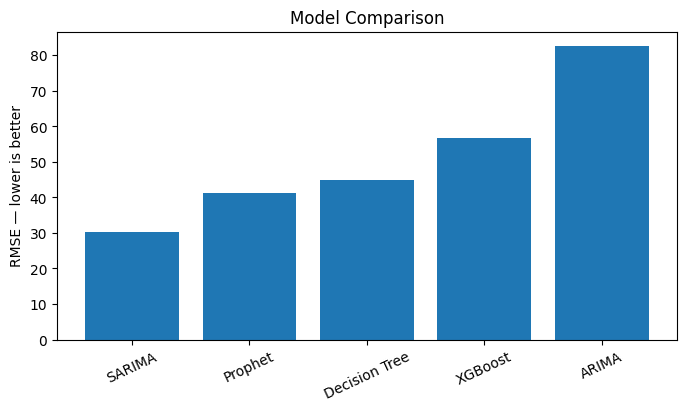

In [14]:
plt.figure(figsize=(8, 4))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("Model Comparison")
plt.ylabel("RMSE — lower is better")
plt.xticks(rotation=25)

plt.show()


## 10. Plot Forecasts

For a clean visual comparison, we first plot the statistical models against the original test period.


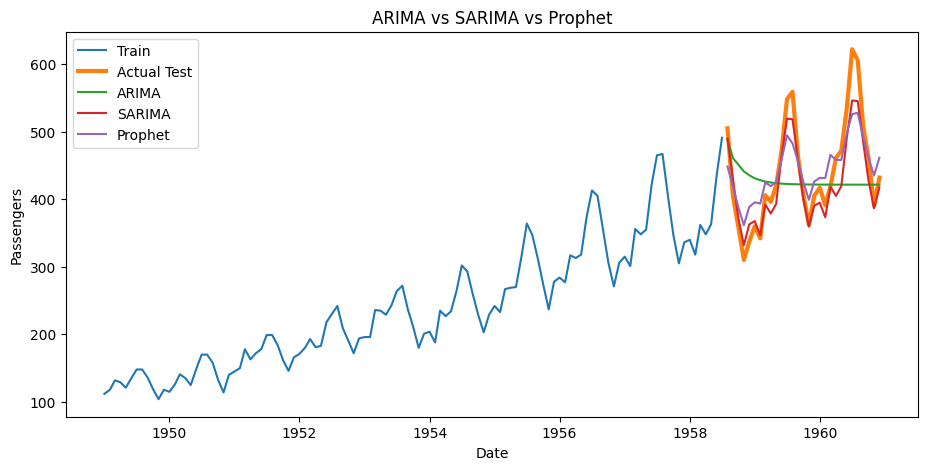

In [15]:
plt.figure(figsize=(11, 5))

plt.plot(
    train["date"],
    train["Passengers"],
    label="Train"
)

plt.plot(
    test["date"],
    test["Passengers"],
    label="Actual Test",
    linewidth=3
)

plt.plot(
    test["date"],
    arima_pred,
    label="ARIMA"
)

plt.plot(
    test["date"],
    sarima_pred,
    label="SARIMA"
)

plt.plot(
    test["date"],
    prophet_pred,
    label="Prophet"
)

plt.title("ARIMA vs SARIMA vs Prophet")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()

plt.show()


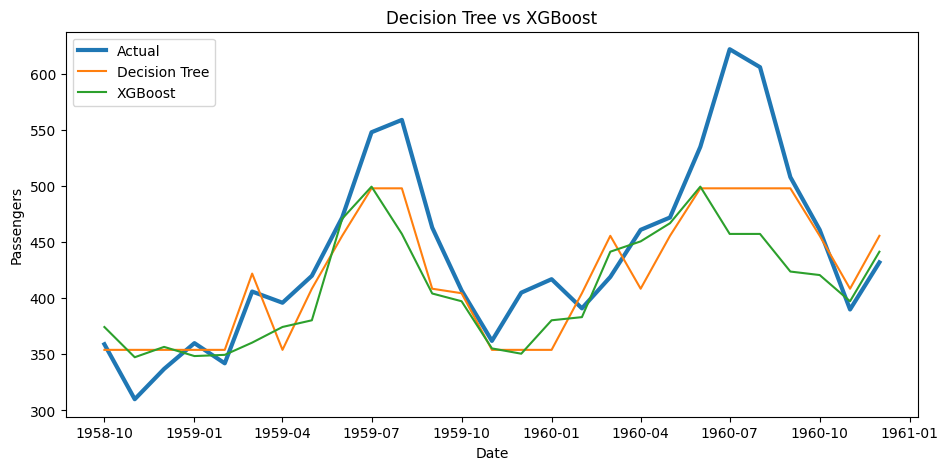

In [16]:
plt.figure(figsize=(11, 5))

plt.plot(
    test_ml["date"],
    y_test,
    label="Actual",
    linewidth=3
)

plt.plot(
    test_ml["date"],
    dt_pred,
    label="Decision Tree"
)

plt.plot(
    test_ml["date"],
    xgb_pred,
    label="XGBoost"
)

plt.title("Decision Tree vs XGBoost")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()

plt.show()


# Simple Interpretation

| Model | Main idea |
|---|---|
| **ARIMA** | Uses past values and past forecast errors |
| **SARIMA** | ARIMA + seasonal patterns |
| **Prophet** | Trend + seasonality + flexible time-series components |
| **Decision Tree** | Learns rules from lagged values |
| **XGBoost** | Combines many small trees sequentially to improve prediction |

### Main distinction

**ARIMA, SARIMA, and Prophet** are designed specifically for time series.

**Decision Tree and XGBoost** are general machine-learning models, so we need to create time-related features such as lags before fitting them.


# Exercise: Stock Market Forecasting — Tesla (TSLA)

In this exercise, repeat the same forecasting workflow using **Tesla (TSLA)** daily stock prices.

## Task

1. Download approximately **5 years** of TSLA stock-price data.
2. Use the **closing price** as the target variable.
3. Split the data chronologically into **80% training** and **20% testing**.
4. Fit the following models:

   - ARIMA
   - SARIMA
   - Prophet
   - Decision Tree
   - XGBoost

5. For Decision Tree and XGBoost, create lagged variables:

   - `lag_1`
   - `lag_2`
   - `lag_5`

6. Compare all models using:

   - RMSE
   - MAE

7. Plot the forecasts against the actual stock prices.

---

Try the exercise yourself before opening the solution below.


# Solution: Stock Market Forecasting — Tesla (TSLA)

The following cells provide a complete solution using the same five models as the AirPassengers example.


In [17]:
# Run once if needed
# %pip install yfinance

import yfinance as yf


## 1. Download TSLA Data

In [18]:
stock = yf.download(
    "TSLA",
    period="5y",
    auto_adjust=False,
    progress=False
)

stock.head()


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2021-10-04,260.510010,260.510010,268.989990,258.706665,265.500000,91449900
2021-10-05,260.196655,260.196655,265.769989,258.066681,261.600006,55297800
2021-10-06,260.916656,260.916656,262.220001,257.739990,258.733337,43898400
2021-10-07,264.536682,264.536682,268.333344,261.126678,261.820007,57587400
2021-10-08,261.829987,261.829987,265.459991,260.303345,265.403320,50215800


In [19]:
# yfinance may return MultiIndex columns.
if isinstance(stock.columns, pd.MultiIndex):
    stock.columns = stock.columns.get_level_values(0)

stock = stock.reset_index()

stock = stock.rename(
    columns={
        "Date": "date",
        "Close": "close"
    }
)

stock = stock[["date", "close"]].dropna()

stock.head()


Price,date,close
0,2021-10-04,260.510010
1,2021-10-05,260.196655
2,2021-10-06,260.916656
3,2021-10-07,264.536682
4,2021-10-08,261.829987


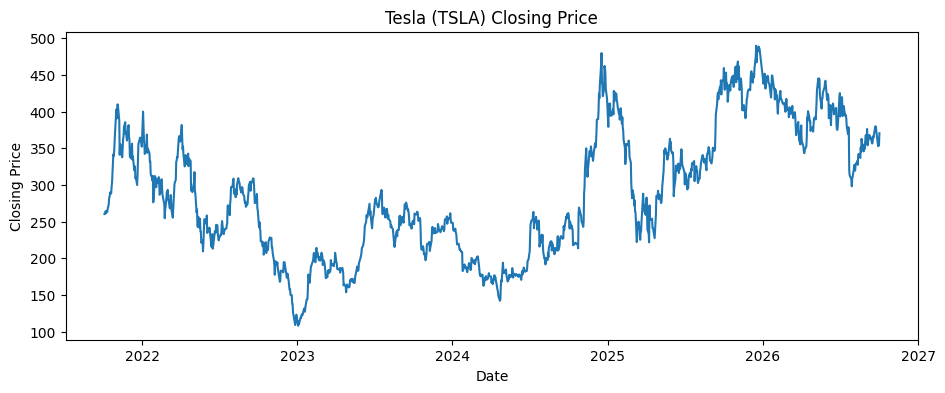

In [20]:
plt.figure(figsize=(11, 4))

plt.plot(stock["date"], stock["close"])

plt.title("Tesla (TSLA) Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()


## 2. Train / Test Split

In [21]:
split = int(len(stock) * 0.8)

train_stock = stock.iloc[:split].copy()
test_stock = stock.iloc[split:].copy()

print("Training observations:", len(train_stock))
print("Test observations:", len(test_stock))


Training observations: 1004
Test observations: 251


## 3. ARIMA Solution

In [22]:
arima_stock = ARIMA(
    train_stock["close"],
    order=(2, 1, 2)
)

arima_stock_fit = arima_stock.fit()

arima_stock_pred = arima_stock_fit.forecast(
    steps=len(test_stock)
)

arima_stock_pred.head()


,predicted_mean
1004,437.514060
1005,435.623011
1006,437.542454
1007,435.917210
1008,437.003166


## 4. SARIMA Solution

For daily stock prices, strong fixed calendar seasonality is not always present.  
To keep the exercise simple, we use a **5-day seasonal period** to represent the trading week.


In [23]:
sarima_stock = SARIMAX(
    train_stock["close"],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 5)
)

sarima_stock_fit = sarima_stock.fit(disp=False)

sarima_stock_pred = sarima_stock_fit.forecast(
    steps=len(test_stock)
)

sarima_stock_pred.head()


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


,predicted_mean
1004,435.104218
1005,433.902669
1006,434.260080
1007,432.326793
1008,433.342236


## 5. Prophet Solution

In [24]:
prophet_stock_train = train_stock.rename(
    columns={
        "date": "ds",
        "close": "y"
    }
)

prophet_stock_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_stock_model.fit(prophet_stock_train)

future_stock = test_stock[["date"]].rename(
    columns={"date": "ds"}
)

prophet_stock_forecast = prophet_stock_model.predict(
    future_stock
)

prophet_stock_pred = prophet_stock_forecast["yhat"]

prophet_stock_pred.head()


,yhat
0,362.993477
1,352.054864
2,347.141613
3,343.430966
4,338.634868


## 6. Create Lag Features for Decision Tree and XGBoost

Machine-learning models need predictor variables.  
We create lagged closing prices:

- yesterday: `lag_1`
- two trading days ago: `lag_2`
- five trading days ago: `lag_5`


In [25]:
stock_ml = stock.copy()

stock_ml["lag_1"] = stock_ml["close"].shift(1)
stock_ml["lag_2"] = stock_ml["close"].shift(2)
stock_ml["lag_5"] = stock_ml["close"].shift(5)

stock_ml = stock_ml.dropna().reset_index(drop=True)

stock_ml.head()


Price,date,close,lag_1,lag_2,lag_5
0,2021-10-11,263.980011,261.829987,264.536682,260.510010
1,2021-10-12,268.573334,263.980011,261.829987,260.196655
2,2021-10-13,270.359985,268.573334,263.980011,260.916656
3,2021-10-14,272.773346,270.359985,268.573334,264.536682
4,2021-10-15,281.010010,272.773346,270.359985,261.829987


In [26]:
split_ml = int(len(stock_ml) * 0.8)

train_stock_ml = stock_ml.iloc[:split_ml].copy()
test_stock_ml = stock_ml.iloc[split_ml:].copy()

features_stock = [
    "lag_1",
    "lag_2",
    "lag_5"
]

X_train_stock = train_stock_ml[features_stock]
y_train_stock = train_stock_ml["close"]

X_test_stock = test_stock_ml[features_stock]
y_test_stock = test_stock_ml["close"]


## 7. Decision Tree Solution

In [27]:
dt_stock = DecisionTreeRegressor(
    max_depth=4,
    random_state=123
)

dt_stock.fit(
    X_train_stock,
    y_train_stock
)

dt_stock_pred = dt_stock.predict(
    X_test_stock
)

dt_stock_pred[:5]


array([435.78592597, 435.78592597, 435.78592597, 435.78592597,
       435.78592597])

## 8. XGBoost Solution

In [28]:
xgb_stock = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=123
)

xgb_stock.fit(
    X_train_stock,
    y_train_stock
)

xgb_stock_pred = xgb_stock.predict(
    X_test_stock
)

xgb_stock_pred[:5]


array([447.23303, 458.4036 , 447.23303, 433.83942, 427.70212],
      dtype=float32)

## 9. Compare Accuracy

In [29]:
stock_results = []

# Time-series models
for name, pred in [
    ("ARIMA", arima_stock_pred),
    ("SARIMA", sarima_stock_pred),
    ("Prophet", prophet_stock_pred)
]:
    rmse, mae = evaluate(
        test_stock["close"],
        pred
    )

    stock_results.append(
        [name, rmse, mae]
    )

# Machine-learning models
for name, pred in [
    ("Decision Tree", dt_stock_pred),
    ("XGBoost", xgb_stock_pred)
]:
    rmse, mae = evaluate(
        y_test_stock,
        pred
    )

    stock_results.append(
        [name, rmse, mae]
    )

stock_results_df = pd.DataFrame(
    stock_results,
    columns=[
        "Model",
        "RMSE",
        "MAE"
    ]
)

stock_results_df = stock_results_df.sort_values(
    "RMSE"
)

stock_results_df


,Model,RMSE,MAE
4,XGBoost,13.969799,10.502518
3,Decision Tree,15.900058,11.458108
1,SARIMA,37.057814,29.024534
0,ARIMA,53.019139,41.849119
2,Prophet,60.757537,54.298785


### TSLA Error Table — All 5 Models

This table compares the forecast errors for ARIMA, SARIMA, Prophet, Decision Tree, and XGBoost on the stock-market exercise.


In [31]:
stock_error_table = stock_results_df.copy()

stock_error_table["RMSE"] = stock_error_table["RMSE"].round(2)
stock_error_table["MAE"] = stock_error_table["MAE"].round(2)

stock_error_table = stock_error_table[
    ["Model", "RMSE", "MAE"]
].sort_values("RMSE")

stock_error_table


,Model,RMSE,MAE
4,XGBoost,13.97,10.50
3,Decision Tree,15.90,11.46
1,SARIMA,37.06,29.02
0,ARIMA,53.02,41.85
2,Prophet,60.76,54.30


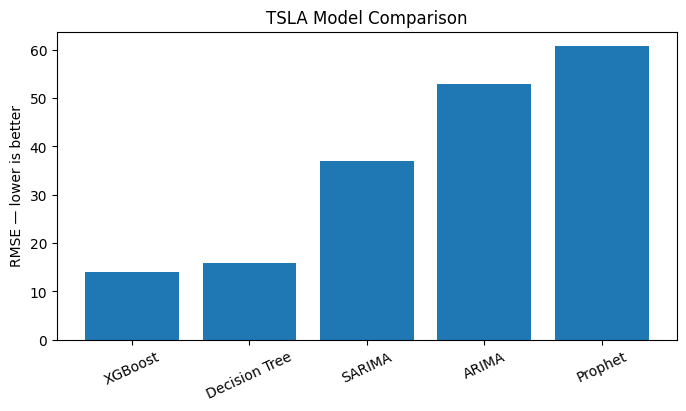

In [32]:
plt.figure(figsize=(8, 4))

plt.bar(
    stock_results_df["Model"],
    stock_results_df["RMSE"]
)

plt.title("TSLA Model Comparison")
plt.ylabel("RMSE — lower is better")
plt.xticks(rotation=25)

plt.show()


## 10. Plot ARIMA, SARIMA, and Prophet

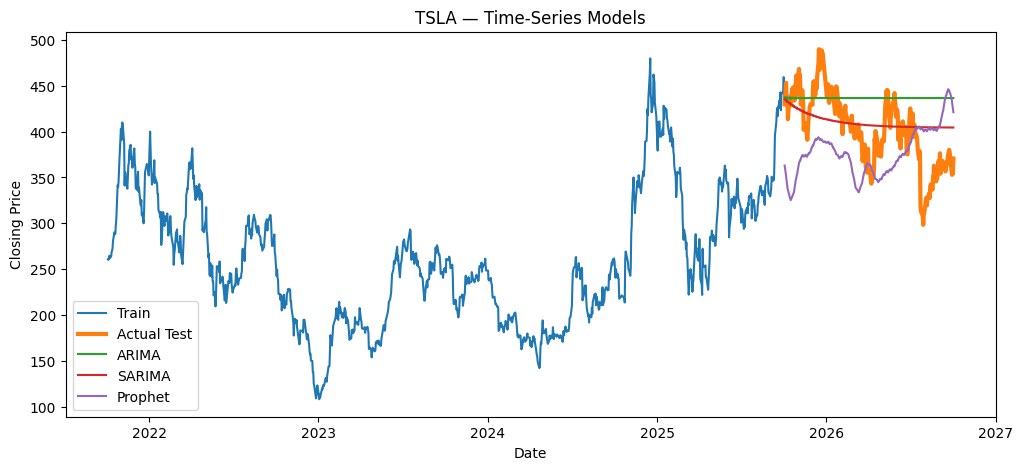

In [33]:
plt.figure(figsize=(12, 5))

plt.plot(
    train_stock["date"],
    train_stock["close"],
    label="Train"
)

plt.plot(
    test_stock["date"],
    test_stock["close"],
    label="Actual Test",
    linewidth=3
)

plt.plot(
    test_stock["date"],
    arima_stock_pred,
    label="ARIMA"
)

plt.plot(
    test_stock["date"],
    sarima_stock_pred,
    label="SARIMA"
)

plt.plot(
    test_stock["date"],
    prophet_stock_pred,
    label="Prophet"
)

plt.title("TSLA — Time-Series Models")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.show()


## 11. Plot Decision Tree and XGBoost

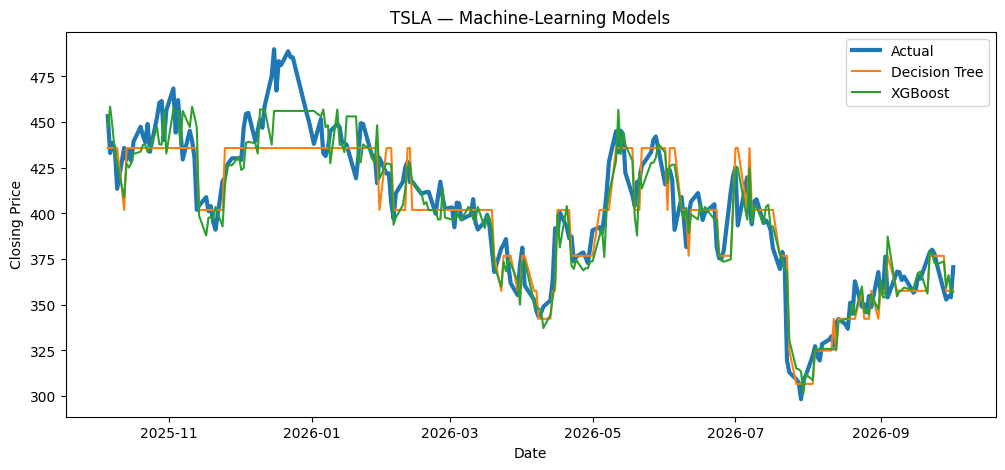

In [34]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_stock_ml["date"],
    y_test_stock,
    label="Actual",
    linewidth=3
)

plt.plot(
    test_stock_ml["date"],
    dt_stock_pred,
    label="Decision Tree"
)

plt.plot(
    test_stock_ml["date"],
    xgb_stock_pred,
    label="XGBoost"
)

plt.title("TSLA — Machine-Learning Models")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.show()


## Exercise Discussion

After running the models, answer these questions:

1. Which model has the lowest RMSE?
2. Does adding seasonality improve ARIMA?
3. How does Prophet compare with ARIMA and SARIMA?
4. Does XGBoost outperform a single Decision Tree?
5. Why might stock prices be more difficult to forecast than AirPassengers?
6. Is forecasting the **price level** necessarily the best approach for financial applications?
